In [1]:
import matplotlib.pyplot as plt
import numpy as np

import spd.initial_conditions as ic
from spd.sdfb_simulator import SDFB_Simulator

from superfv import HydroSolver, ics, FallbackCascade, MUSCL_SlopeLimiter
from superfv.tools.turbulence import compute_turbulence_crossing_time as compute_turbulence_crossing_time

from functools import partial

In [2]:
seed = 1
M = 50
slope = 0.0

gamma = 1.01
N = 64
p = 3

Nelements = N // (p + 1)

In [3]:
sim_fv = HydroSolver(
    gamma=gamma,
    ic=partial(ics.decaying_isotropic_turbulence, M=M, seed=seed, slope=slope),
    nx=N,
    ny=N,
    p=p,
    use_MOOD=True,
    max_revs=2,
    fallback_cascade=FallbackCascade.MUSCL0,
    rtol=1e-5,
    omit_vars_from_NAD=["vx", "vy", "vz"],
    MUSCL_limiter=MUSCL_SlopeLimiter.MINMOD,
    positivity_guard=False,
    rho_min=0.0,
    P_min=0.0,
)
t_cross = compute_turbulence_crossing_time(sim_fv)
sim_fv.run(t_cross)

/Users/jonathan/Desktop/FV vs SD/superfv/superfv/initial_conditions.py:1031: RuntimeWarning: divide by zero encountered in power
  ENV = xp.where(K > 0, (K / kref) ** ((slope - (ndim - 1)) / 2), 0.0)
/Users/jonathan/Desktop/FV vs SD/superfv/superfv/initial_conditions.py:1041: RuntimeWarning: divide by zero encountered in divide
  invK2 = xp.where(K2 > 0.0, 1.0 / K2, 0.0)


SuperFV: 157 steps | t=2.00e-02/2.00e-02, dt=4.09e-05 | rho_min=6.68e-03 | E_cons=0.00e+00 | wall=3.45e+00s (done)


In [4]:
sim_old = SDFB_Simulator(
    N=(Nelements,Nelements),
    p=p,
    init_fct=ic.decaying_isotropic_turbulence(M=M, seed=seed, slope=slope),
    gamma=gamma,
    cfl_coeff=0.8,
    use_cupy=False,
    time_integrator="rk3",
    tolerance=1e-5,
    min_rho=0.0,
    min_P=0.0,
    blending=False,
    second_fallback=True,
    nrevmax=3,
)
sim_old.perform_time_evolution(t_cross)

/Users/jonathan/Desktop/FV vs SD/spd/spd/finite_volume/muscl.py:144: RuntimeWarning: divide by zero encountered in divide
  ratio = SlopeR/SlopeL
/Users/jonathan/Desktop/FV vs SD/spd/spd/finite_volume/muscl.py:144: RuntimeWarning: invalid value encountered in divide
  ratio = SlopeR/SlopeL


t=0.02, steps taken 1062, time taken 14.273, bzcps = 0.0


/var/folders/y9/m318q_ps0l19lz859k2_tfr00000gn/T/ipykernel_27082/2514119747.py:9: RuntimeWarning: invalid value encountered in log10
  log10_rho_sd = np.log10(sim_old.transpose_to_fv(sim_old.regular_mesh(sim_old.dm.W_cv))[sim_old._d_].T)


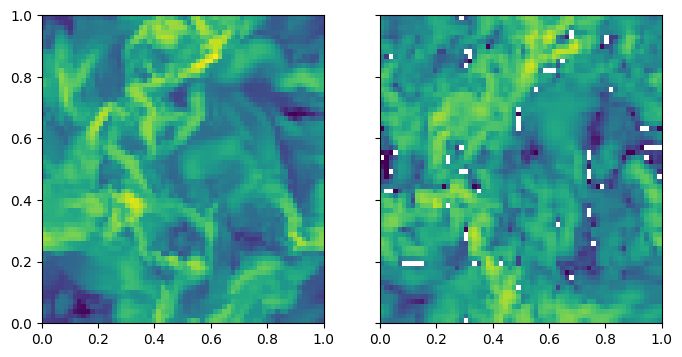

In [5]:
fig, axs = plt.subplots(1, 2, sharex=True, sharey=True, figsize=(8, 4))

# ax.plot(sim_fv.mesh.centers[0], sim_fv.snapshot_history[-1].w[sim_fv.idx("vx"), :, 0, 0])
# x_old = 0.5 * (sim_old.regular_faces()[0][:-1] + sim_old.regular_faces()[0][1:])
# ax.plot(x_old, sim_old.transpose_to_fv(sim_old.dm.W_cv)[sim_old._vx_], '--')

log10_rho_fv = np.log10(sim_fv.snapshot_history[-1].w[sim_fv.idx("rho"), :, :, 0])
x_fv, y_fv = sim_fv.mesh.faces[0], sim_fv.mesh.faces[1]
log10_rho_sd = np.log10(sim_old.transpose_to_fv(sim_old.regular_mesh(sim_old.dm.W_cv))[sim_old._d_].T)
x_sd, y_sd = sim_old.regular_faces()[0], sim_old.regular_faces()[1]
# log10_rho_sd = np.log10(sim_old.transpose_to_fv(sim_old.dm.W_cv)[sim_old._d_].T)
# x_sd = sim_old.ho_scheme.faces["x"][sim_old.Nghc:-sim_old.Nghc]
# y_sd = sim_old.ho_scheme.faces["y"][sim_old.Nghc:-sim_old.Nghc]

log10_rho_min = min(np.min(log10_rho_fv), np.min(log10_rho_sd))
log10_rho_max = max(np.max(log10_rho_fv), np.max(log10_rho_sd))

common = dict(shading="auto", vmin=log10_rho_min, vmax=log10_rho_max)
axs[0].pcolormesh(x_fv, y_fv, log10_rho_fv, **common)
axs[1].pcolormesh(x_sd, y_sd, log10_rho_sd, **common)